# 03 - Revision de correcciones LLM clip por clip

Este notebook revisa sugerencias de correccion textual generadas por un LLM grande para `CHARLA SOBRE EL AMOR Y EL DESAMOR`.

El texto original no se modifica. La salida del LLM queda como propuesta auditable: raw del repo, raw que devolvio el LLM, texto sugerido, flags, decision automatica y video de revision.

## 1. Setup y artefactos

El notebook no define helpers: toda la logica vive en `data_cleaning/src/llm_text_correction_review.py` y `data_cleaning/src/llm_text_corrections.py`.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data_cleaning" / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from data_cleaning.src.llm_text_correction_review import (
    accepted_correction_rows,
    display_review_video,
    display_source_metadata,
    export_review_webm,
    load_review_artifacts,
    load_source_metadata,
    rejected_suggestion_rows,
    render_diff_examples,
    select_diff_examples,
    select_video_examples,
    show_table,
    summary_table_rows,
)

BASE_DIR = "data_cleaning/outputs/llm_text_corrections/charla_amor_desamor"
WEBM_DIR = "data_cleaning/outputs/llm_text_corrections/charla_amor_desamor/review_webm"
artifacts = load_review_artifacts(ROOT, BASE_DIR)
summary = artifacts["summary"]
rows = artifacts["rows"]
source_id = rows[0]["source_id"] if rows else "CHARLA SOBRE EL AMOR Y EL DESAMOR"
metadata = load_source_metadata(ROOT, source_id)

print("Repo detectado:", ROOT.name)
print("Summary:", artifacts["summary_path"].relative_to(ROOT))
print("Manifest:", artifacts["manifest_path"].relative_to(ROOT))
print("Respuesta cruda LLM:", artifacts["raw_suggestions_path"].relative_to(ROOT))
print("Filas:", len(rows))


Repo detectado: labios-argentos
Summary: data_cleaning\outputs\llm_text_corrections\charla_amor_desamor\summary.json
Manifest: data_cleaning\outputs\llm_text_corrections\charla_amor_desamor\review_manifest.csv
Respuesta cruda LLM: data_cleaning\outputs\llm_text_corrections\charla_amor_desamor\llm_suggestions.raw.json
Filas: 233


## 2. Fuente y cobertura

Esta fuente esta registrada como `CHARLA SOBRE EL AMOR Y EL DESAMOR`; el hablante principal en metadata es Coscu. Si aparece Coscu en video, eso coincide con el metadata del repo.

In [2]:
display_source_metadata(metadata)
show_table(summary_table_rows(summary), ["grupo", "valor", "cantidad"])

carpeta,hablante_principal,canal_o_fuente,url,notas
CHARLA SOBRE EL AMOR Y EL DESAMOR,Coscu,Coscu,https://www.youtube.com/watch?v=z-jbSKM49fo,"Cubre registro emocional e informal, pero sigue en mundo streamer."


grupo,valor,cantidad
actions,corrected,34
actions,keep,177
actions,uncertain,22
review_status,accept_correction,31
review_status,keep_raw,177
review_status,reject_suggestion,25
validation_flags,cambio_grande_detectado,1
validation_flags,correccion_baja_confianza,1
risk_flags,cambio_grande,16
risk_flags,correccion_inferida,32


## 3. Correcciones aceptadas automaticamente

No hay revision manual para casos medio medio. El validador decide: aceptar correcciones chicas y confiables, conservar raw, o rechazar la sugerencia.

In [3]:
accepted_preview = accepted_correction_rows(rows, limit=8)
show_table(accepted_preview, ["clip", "raw", "suggested", "confidence", "risk_flags"], max_chars=90)
print("Correcciones aceptadas:", summary["review_status"].get("accept_correction", 0))


clip,raw,suggested,confidence,risk_flags
clip_0001,la vida aca voy a aparecer un hippie o esas finas que leen el horoscopo,la vida aca voy a parecer un hippie o esas minas que leen el horoscopo,0.97,jerga
clip_0013,ojo yo veo el numero y no les voy a negarme me motivo me motivo,ojo yo veo el numero y no les voy a negar me motivo me motivo,0.9,correccion_inferida|repeticion
clip_0017,agraecido siempre pero vale destacar que en un momento critico porque es un momento cri...,agradecido siempre pero vale destacar que en un momento critico porque es un momento cr...,0.99,-
clip_0028,se tiene un culito lindo mejor mejor,si tiene un culito lindo mejor mejor,0.96,jerga
clip_0031,pero que haga deporte ir a verla imaginante que juega el futbol,pero que haga deporte ir a verla imaginate que juega el futbol,0.98,-
clip_0038,desde los 16 a los 23 y medio yo pensaba que la vida era agarchar,desde los 16 a los 23 y medio yo pensaba que la vida era garchar,0.99,jerga|insulto
clip_0048,la van a pasar mal tambien la van a pasar como el or,la van a pasar mal tambien la van a pasar como el orto,0.99,insulto
clip_0056,lo bueno es dur el objetivo ideal te va a costar,lo bueno es duro el objetivo ideal te va a costar,0.78,correccion_inferida


Correcciones aceptadas: 31


## 4. Sugerencias rechazadas

Estas sugerencias no se aplican: incertidumbre, baja confianza, mismatch de raw, cambio grande o riesgo de alucinacion. En esos casos se conserva el texto original.

In [4]:
rejected_preview = rejected_suggestion_rows(rows, limit=8)
show_table(
    rejected_preview,
    ["clip", "action", "confidence", "raw_repo", "raw_llm", "suggested", "validation", "risk"],
    max_chars=75,
)
print("Sugerencias rechazadas:", summary["review_status"].get("reject_suggestion", 0))


clip,action,confidence,raw_repo,raw_llm,suggested,validation,risk
clip_0000,corrected,0.35,voy a antereccionar maria del cerro y ahora que hay un monton de gente e...,voy a antereccionar maria del cerro y ahora que hay un monton de gente e...,voy a antes de reaccionar a maria becerra y ahora que hay un monton de g...,correccion_baja_confianza,nombre_propio|cambio_grande|correccion_inferida|posible_alucinacion|requ...
clip_0036,uncertain,0.5,no le tengan miedo al amor no hablan como hice este boludo,no le tengan miedo al amor no hablan como hice este boludo,no le tengan miedo al amor no hablan como hice este boludo,-,jerga|insulto|correccion_inferida|requiere_video
clip_0037,uncertain,0.5,no hablan como hice este boludo yo tenia desde los 16 a los 23 y medio q...,no hablan como hice este boludo yo tenia desde los 16 a los 23 y medio q...,no hablan como hice este boludo yo tenia desde los 16 a los 23 y medio q...,-,jerga|insulto|correccion_inferida|requiere_video
clip_0053,uncertain,0.45,lo importante como es amarte en una pareja en una relacion estable,lo importante como es amarte en una pareja en una relacion estable,lo importante como es amarte en una pareja en una relacion estable,-,cambio_grande|correccion_inferida|posible_alucinacion|requiere_video
clip_0074,uncertain,0.45,eso es otro punto level amigo tu casilla llena de mensajes,eso es otro punto level amigo tu casilla llena de mensajes,eso es otro punto level amigo tu casilla llena de mensajes,-,jerga|insulto|correccion_inferida|requiere_video
clip_0089,uncertain,0.55,lo que se disfruta mucho humo dice uno,lo que se disfruta mucho humo dice uno,lo que se disfruta mucho humo dice uno,-,correccion_inferida|requiere_video
clip_0123,uncertain,0.45,la interferencia todo ese amor que vos dabas y dabas y dabas no va a nin...,la interferencia todo ese amor que vos dabas y dabas y dabas no va a nin...,la interferencia todo ese amor que vos dabas y dabas y dabas no va a nin...,-,cambio_grande|correccion_inferida|posible_alucinacion|requiere_video
clip_0124,corrected,0.86,porque ya no hay nadie aqui a andar de amor pero que pasa,porque ya no hay nadie aqui a andar de amor pero que pasa,porque ya no hay nadie a quien dar amor pero que pasa,-,cambio_grande|correccion_inferida


Sugerencias rechazadas: 25


## 5. Reemplazos legibles

Esta tabla muestra `antes -> despues` sin colores dif?ciles de leer. Cada fila es un cambio de palabras detectado por el diff.

In [5]:
render_diff_examples(select_diff_examples(rows, per_group=4))


clip,decision,action,confidence,antes,despues,risk,validation
clip_0001,accept_correction,corrected,0.97,aparecer,parecer,jerga,-
clip_0001,accept_correction,corrected,0.97,finas,minas,jerga,-
clip_0013,accept_correction,corrected,0.9,negarme,negar,correccion_inferida|repeticion,-
clip_0017,accept_correction,corrected,0.99,agraecido,agradecido,-,-
clip_0028,accept_correction,corrected,0.96,se,si,jerga,-
clip_0000,reject_suggestion,corrected,0.35,antereccionar,antes de reaccionar a,nombre_propio|cambio_grande|correccion_inferida|posible_alucinacion|requiere_video,correccion_baja_confianza
clip_0000,reject_suggestion,corrected,0.35,del cerro,becerra,nombre_propio|cambio_grande|correccion_inferida|posible_alucinacion|requiere_video,correccion_baja_confianza
clip_0036,reject_suggestion,uncertain,0.5,-,-,jerga|insulto|correccion_inferida|requiere_video,-
clip_0037,reject_suggestion,uncertain,0.5,-,-,jerga|insulto|correccion_inferida|requiere_video,-
clip_0053,reject_suggestion,uncertain,0.45,-,-,cambio_grande|correccion_inferida|posible_alucinacion|requiere_video,-


## 6. Video de revision compatible con VS Code
Se muestran 4 clips de revision. Cada clip se exporta como MP4 H.264 con audio MP3, porque VS Code puede mostrar MP4 con AAC pero quedarse sin sonido. Tambien queda un audio MP3 separado como respaldo.


### clip_0001 - accept_correction

raw_repo,suggested,risk,validation
la vida aca voy a aparecer un hippie o esas finas que leen el horoscopo,la vida aca voy a parecer un hippie o esas minas que leen el horoscopo,jerga,-


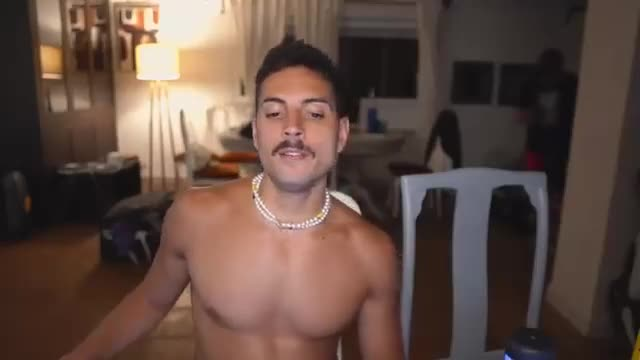

Audio separado de respaldo:

### clip_0013 - accept_correction

raw_repo,suggested,risk,validation
ojo yo veo el numero y no les voy a negarme me motivo me motivo,ojo yo veo el numero y no les voy a negar me motivo me motivo,correccion_inferida|repeticion,-


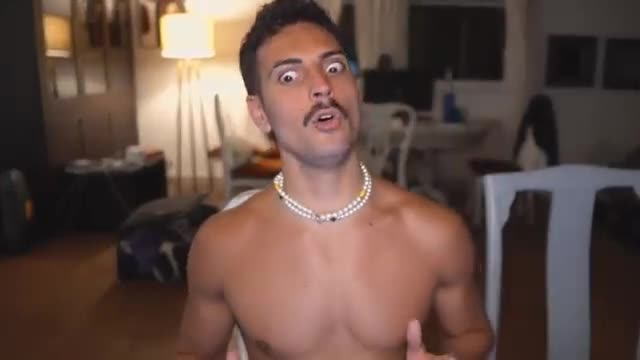

Audio separado de respaldo:

### clip_0000 - reject_suggestion

raw_repo,suggested,risk,validation
voy a antereccionar maria del cerro y ahora que hay un monton de gente en el chat les quiero decir algo,voy a antes de reaccionar a maria becerra y ahora que hay un monton de gente en el chat les quiero decir algo,nombre_propio|cambio_grande|correccion_inferida|posible_alucinacion|requiere_video,correccion_baja_confianza


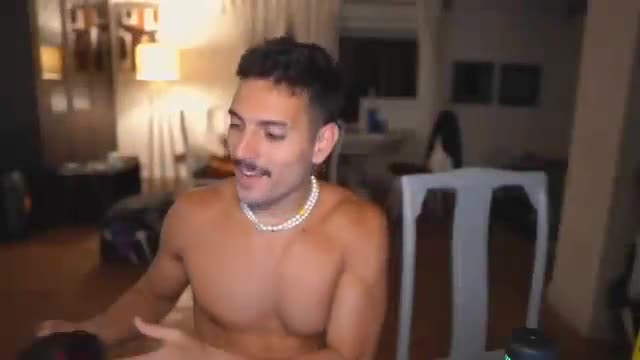

Audio separado de respaldo:

### clip_0036 - reject_suggestion

raw_repo,suggested,risk,validation
no le tengan miedo al amor no hablan como hice este boludo,no le tengan miedo al amor no hablan como hice este boludo,jerga|insulto|correccion_inferida|requiere_video,-


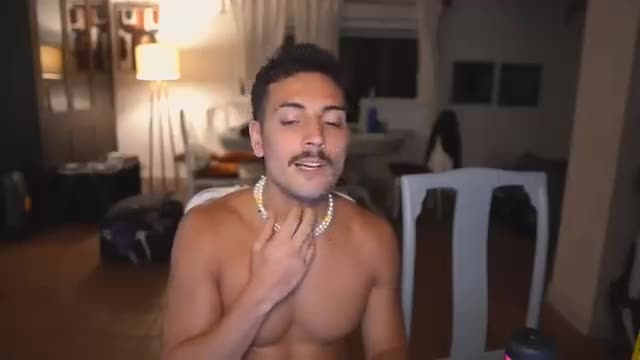

Audio separado de respaldo:

In [6]:
video_examples = select_video_examples(rows, limit=4)
video_examples = export_review_webm(ROOT, video_examples, WEBM_DIR, force=False)

for row in video_examples:
    display(Markdown(f"### {row['clip_id']} - {row['review_status']}"))
    show_table([
        {
            "raw_repo": row["source_raw_text"],
            "suggested": row["suggested_text"],
            "risk": row["risk_flags"] or "-",
            "validation": row["validation_flags"] or "-",
        }
    ], ["raw_repo", "suggested", "risk", "validation"], max_chars=120)

    if row.get("review_thumbnail_exists"):
        display(Image(filename=row["review_thumbnail_path"], width=360))

    display_review_video(row, ROOT, width=640)


## 7. Lectura final

Resultado de este notebook:

- El LLM propuso cambios, pero el validador no acepta todo automaticamente.
- Los estados operativos son `accept_correction`, `keep_raw` y `reject_suggestion`.
- El mismatch de `raw_text` del LLM queda rechazado, no oculto.
- Los `.txt` locales coinciden con el split (`txt_matches_source`), y los videos se muestran desde la carpeta exacta de la fuente.
- Las correcciones aceptadas pueden usarse como candidato de limpieza; las rechazadas conservan el raw.